# Part A - Concept Application

## Titanic Dataset EDA

In [1]:
%pip install pandas
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import os

In [3]:
os.makedirs("plots", exist_ok=True)

In [4]:
df = pd.read_csv("./data/titanic-dataset.csv")

## Basic Exploration

### Displaying first 5 rows

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Displaying last 5 rows

In [6]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### Shape and Column Names

In [7]:
df.shape

(891, 12)

In [8]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

## Data Cleaning

### Identity Missing Values

In [9]:
print("="*28)
print("Number of Missing Values:")
print("="*28)
df.isnull().sum()

Number of Missing Values:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df["Age"].dtype

dtype('float64')

In [11]:
df["Embarked"].dtype


dtype('O')

In [12]:
df["Cabin"].dtype

dtype('O')

#### Missing Value Percentage

In [13]:
print("="*28)
print("Percentage Of Missing Values:")
print("="*28)
print()
print(df.isnull().sum()/len(df) *100)

Percentage Of Missing Values:

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


In [14]:
age = df["Age"].dropna()

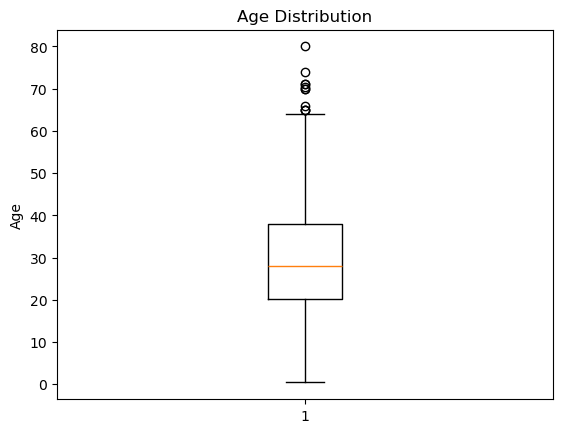

In [15]:
plt.boxplot(age)
plt.ylabel("Age")
plt.title("Age Distribution")

plt.savefig("plots/age_box_plot.png")
plt.show()

### Fill or drop missing values


#### Fill numerical missing values with median

In [16]:
df['Age'] = df['Age'].fillna(df['Age'].median())

#### Fill categorical missing values with mode

In [17]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

#### Drop column with too many missing values

In [18]:
df = df.drop(columns=['Cabin'])

In [96]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Descriptive Statistics

In [97]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Categorical Analysis

#### Find unique values


In [19]:
df.describe(include='object')

,Name,Sex,Ticket,Embarked
count,891,891,891,891
unique,891,2,681,3
top,"Braund, Mr. Owen Harris",male,347082,S
freq,1,577,7,646


In [20]:
df["Sex"].unique()

array(['male', 'female'], dtype=object)

In [21]:
df["Embarked"].unique()

array(['S', 'C', 'Q'], dtype=object)

In [22]:
df["Ticket"].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

In [23]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Embarked']

#### Show Frequency Count

In [24]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

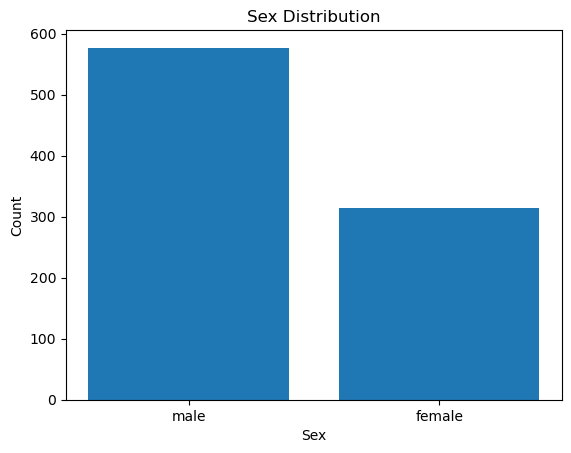

In [25]:
plt.bar(df["Sex"].value_counts().index, df["Sex"].value_counts().values)
plt.title("Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.savefig("plots/sex_distribution.png")
plt.show()

In [26]:
df["Embarked"].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

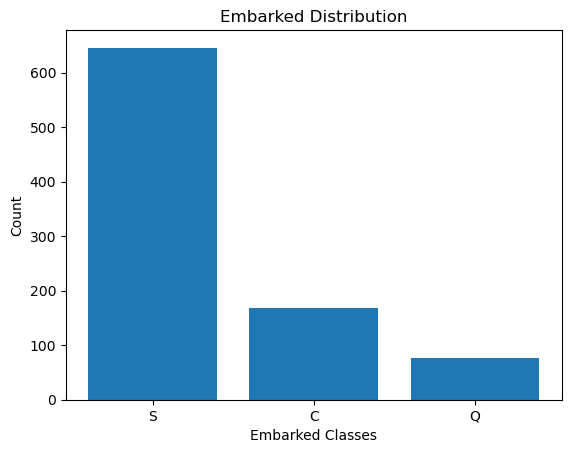

In [27]:
plt.bar(df["Embarked"].value_counts().index, df["Embarked"].value_counts().values)
plt.title("Embarked Distribution")
plt.xlabel("Embarked Classes")
plt.ylabel("Count")
plt.savefig("plots/embarked_distribution.png")
plt.show()

# Part B - Stretch Problem

## Filter Dataset Using Multiple Conditions

### Female passengers older than 25

In [39]:
filtered_df =df[(df["Age"] >25) & (df["Sex"] == "female")]

In [41]:
filtered_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,S


### Male passengers in first class

In [42]:
filtered_df = df[(df["Sex"] == "male" )& (df["Pclass"] == 1)]

In [44]:
filtered_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,S
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,S
30,31,0,1,"Uruchurtu, Don. Manuel E",male,40.0,0,0,PC 17601,27.7208,C
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.0,1,0,PC 17604,82.1708,C


### Passengers who survived and paid fare above 50

In [47]:
filtered_df = df[(df["Survived"] == 1) & (df["Fare"] > 50)]

In [49]:
filtered_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,28.0,1,0,PC 17569,146.5208,C
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,C
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0000,S


## Create New Columns Based on Existing Data

### Family Size

In [50]:
df["FamilySize"] = df["SibSp"] + df["Parch"]

In [51]:
df[["FamilySize","SibSp","Parch"]].head()

,FamilySize,SibSp,Parch
0,1,1,0
1,1,1,0
2,0,0,0
3,1,1,0
4,0,0,0


### Age Group

In [52]:
df["AgeGroup"] = df["Age"].apply(lambda x: "Child" if x < 18 else "Adult")

In [53]:
df[["AgeGroup","Age"]].head()

,AgeGroup,Age
0,Adult,22.0
1,Adult,38.0
2,Adult,26.0
3,Adult,35.0
4,Adult,35.0


### Fare Category

In [54]:
df["FareCategory"] = df["Fare"].apply(lambda x: "High" if x > 50 else "Low")

In [56]:
df[["Fare", "FareCategory"]].head()

,Fare,FareCategory
0,7.2500,Low
1,71.2833,High
2,7.9250,Low
3,53.1000,High
4,8.0500,Low


## Sort Dataset by Numerical Column

### Sort by Fare descending

In [57]:
sorted_df1 = df.sort_values(by="Fare", ascending=False) 
sorted_df1[["Name", "Fare"]].head()

,Name,Fare
258,"Ward, Miss. Anna",512.3292
737,"Lesurer, Mr. Gustave J",512.3292
679,"Cardeza, Mr. Thomas Drake Martinez",512.3292
88,"Fortune, Miss. Mabel Helen",263.0000
27,"Fortune, Mr. Charles Alexander",263.0000


### Sort by Age Ascending

In [59]:
sorted_df2 = df.sort_values(by="Age")
sorted_df2[["Name", "Age"]].head()

,Name,Age
803,"Thomas, Master. Assad Alexander",0.42
755,"Hamalainen, Master. Viljo",0.67
644,"Baclini, Miss. Eugenie",0.75
469,"Baclini, Miss. Helene Barbara",0.75
831,"Richards, Master. George Sibley",0.83


### Sort by Family Size descending

In [60]:
sorted_df3 = df.sort_values(by="FamilySize", ascending=False)
sorted_df3[["Name", "FamilySize"]].head()

,Name,FamilySize
180,"Sage, Miss. Constance Gladys",10
846,"Sage, Mr. Douglas Bullen",10
792,"Sage, Miss. Stella Anna",10
201,"Sage, Mr. Frederick",10
159,"Sage, Master. Thomas Henry",10


## Group Data and Compute Mean

### Mean Fare by Passenger Class

In [62]:
group1 = df.groupby("Pclass")["Fare"].mean() 
print(group1)

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


### Mean Age by Gender

In [63]:
group2 = df.groupby("Sex")["Age"].mean()
print(group2)

Sex
female    27.929936
male      30.140676
Name: Age, dtype: float64


### Mean Survival by Embarked Port

In [66]:
group3 = df.groupby("Embarked")["Survived"].mean()
print(group3)

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64
